# Project 2

## Utils

In [523]:
import numpy as np
from math import sqrt, log
from scipy import stats
from joblib import Parallel, delayed
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [445]:
def f_lambda(a,b,t):
    return a*t**2 + b*t

def insert_into_sorted_list(sorted_list, new_tuple):
    """Inserts a tuple (e, t) into a list sorted in descending order
    based on the second element (t).
    """
    #print(new_tuple)
    new_t = new_tuple[2]
    
    # Iterate through the list to find the correct position
    for i, (_, _,current_t) in enumerate(sorted_list):
        if new_t >= current_t:
            sorted_list.insert(i, new_tuple)
            return sorted_list
            
    # If new_t is smaller than all existing elements,
    # append it to the end.
    sorted_list.append(new_tuple)
    return sorted_list

def first_index_le_zero(arr):
    """Returns the first index where the coordinate is <= 0.
    Returns None if no such coordinate exists.
    """
    # Find all indices where the condition is True
    indices = np.where(arr <= 0)[0]
    
    # If the resulting array is not empty, return the first index
    return indices[0] if indices.size > 0 else None

In [484]:
def sample_acceptance_exponential(f, lambda_max, t):
    Accepted = False
    x = np.random.exponential(scale = 1/lambda_max)
    acceptance_rate = f(x+t)/lambda_max
    u = np.random.uniform()
    if u < acceptance_rate :
        Accepted = True
    return Accepted, x

## Primary task : simulation

### Event based hospital class

In [ ]:
class hostpital_EB :

    def __init__(self, a, b, LOS_Parameters, f_lambda, lambda_3, capacities, limit):
        self.t = 0 # current time

        self.a = a
        self.b = b

        self.lambda_3 = lambda_3
        self.f_lambda1 = lambda t : f_lambda(self.a,self.b,t)
        self.f_lambda2 = lambda t : f_lambda(self.a/5,self.b/5,t)
        self.lambda_max = self.f_lambda1(-b/2*a)
        self.LOS = LOS_Parameters

        self.Capacities = np.array(capacities)
        self.limit = limit

        self.Wards = np.zeros(3) # nb of occupied bed per ward
        self.Ward_history = {i : [] for i in range(3)} # list of number of occupied beds per ward
        self.Flows = np.zeros((3,2)) # History of accepted/refused customers per ward
        self.PL = [] # Priority list

    def sample_inter_arrival(self,w,t):
        if w == 0 :
            return sample_acceptance_exponential(self.f_lambda1, self.lambda_max, t)
        elif w ==1 : 
            return sample_acceptance_exponential(self.f_lambda2, self.lambda_max/5, t)
        elif w ==2 :
            return True, np.random.exponential(1/self.lambda_3)
        
    def reinitialize(self):
        self.PL = []
        self.t = 0
        self.Wards = np.zeros(3)
        self.Flows = np.zeros((3,2))
        self.Ward_history = {i : [] for i in range(3)}
    
    

######################## Schedule functions ###########################

    def schedule_free_bed(self,w):
        sojourn = np.random.lognormal(mean = self.LOS[w][0], sigma=self.LOS[w-1][1])
        insert_into_sorted_list(self.PL,(("FB",w,self.t + sojourn)))

    def schedule_arrival(self,w,t,limit):
        is_accepted = False
        while (not is_accepted) and (t < limit) :
            is_accepted, x = self.sample_inter_arrival(w,t)
            t += x
        if is_accepted :
            insert_into_sorted_list(self.PL,("Arr",w,t))

######################## Event functions ###########################

    def Free_bed(self,w):
        if self.Wards[w] > 0 :
            self.Wards[w] -= 1
            self.Ward_history[w].append((self.Wards[w],self.t)) # New bed available at time t in ward w

    def Arrive_ward(self,w):
        if self.Wards[w] < self.Capacities[w]: # If a bed is available in ward w
            self.Wards[w] += 1 # One more bed occupied
            self.Flows[w][1] += 1 # A patient from ward w is accepted
            self.Ward_history[w].append((self.Wards[w],self.t)) # New occupied bed at time t in ward w
            self.schedule_free_bed(w)
        elif w == 1 and self.Wards[0] < self.Capacities[0]: # If the patient arrives at a full Ward B but space in Ward A
            self.Flows[1][0] += 1 # Refused from Ward B
            self.Arrive_ward(0) # New patient arrives at Ward A
        else : # If no bed is available 
            self.Flows[w][0] += 1 # Patient refused at Ward w
        

###################### Main algorithm : Step_function ###############

    def initialize(self):
        for w in range(3):
            self.schedule_arrival(w,self.t, self.limit)

    def Step_function(self, limit):
        
        if self.t == 0 :
            self.initialize()
            
        Event_type, w, new_t = self.PL.pop() # returns last tuple of PL list

        if new_t < limit :
            self.t = new_t  # update time 
            if Event_type == "Arr" : 
                self.Arrive_ward(w)
                self.schedule_arrival(w, self.t, self.limit)
            else :
                self.Free_bed(w)

        else :
            self.t = limit

    

### Tests

In [442]:
LOS = [(log(4*sqrt(2)),sqrt(log(2))), (log(6*sqrt(2)), sqrt(log(2))), (log(5)*sqrt(2), sqrt(log(2)))]
lambda_3 = 6

nb_A =  30   #30
nb_B =  20   #20
nb_C = 75 - nb_A - nb_B
Capacities = [nb_A,nb_B,nb_C]

limit = 365

a = -1/3650
b = 1/10

In [444]:
H = hostpital_EB(
    a = a,
    b = b,
    LOS_Parameters=LOS,
    f_lambda=f_lambda,
    lambda_3=lambda_3,
    capacities= Capacities,
    limit= limit 
)

#IA = H.sample_inter_arrival(0)
#print(IA, H.t)
limit = 365
epsilon = 0.01
H.reinitialize()
while H.t < limit - epsilon :
    print(H.t)
    H.Step_function(limit)

0
0.06710501614448348
0.11577257857837905
0.14115219844232993
0.4077696554624334
0.52194587639208
0.6563690461137539
0.7676593399727336
0.824236048366254
1.1517615496328146
1.2408537946652547
1.3070548889537978
1.4399021465201056
1.473180001387492
1.5337260834504307
1.6552943389384265
1.7140292066609404
1.9111222319667263
2.0255554128866167
2.225224921743699
2.44757045869132
2.5191503579554975
2.5389856386433416
2.6266882885102887
2.728768075214652
2.7886631573401726
2.83992224255471
2.859805834200666
2.8770863993812132
2.9082536221557227
3.242621588006447
3.352681299884407
3.514266253359151
3.568019204133021
3.5799262030900425
3.664850439873251
4.030958992829759
4.196914129452182
4.294117273200901
4.406916427775162
4.7644613991852935
4.791364095151607
4.810752921671368
5.05674173069672
5.155284751183167
5.182457091009208
5.217496142361761
5.2814409449057615
5.39405026680293
5.486209874224161
5.829426479078989
5.995357180828545
6.027666331190438
6.066440530490296
6.077380721017457
6.12

## Primary performances measures

In [588]:
mu = (H.a*(365**3)/3 + H.b*(365**2)/2)
print("mean of lambda(t) : ",mu/365)

mean of lambda(t) :  6.083333333333334


In [438]:
names = ["A", "B", "C"]
for w in range(3):
    print(f"Ward {names[w]} : {int(np.sum(H.Flows[w][1]))} accepted people \n         {int(np.sum(H.Flows[w][0]))} rejected people")
    L = H.Ward_history[w]
    mean_nb_occupied = (np.sum([(L[i][1]-L[i-1][1])*L[i-1][0] for i in range(1,len(L))]) + (365-L[-1][1])*L[-1][0])/365
    print(f"         {mean_nb_occupied:.4f} mean number of occupied bed")

Ward A : 1217 accepted people 
         985 rejected people
         26.1193 mean number of occupied bed
Ward B : 409 accepted people 
         63 rejected people
         12.9948 mean number of occupied bed
Ward C : 719 accepted people 
         1485 rejected people
         24.3263 mean number of occupied bed


In [504]:
# Probability that all beds are occupied for each of the three patient types
for w in range(3):
    print(f"Probability that all beds are occupied for a patient of type {w} : {H.Flows[w][0]/np.sum(H.Flows[w]):.4f}")

Probability that all beds are occupied for a patient of type 0 : 0.5142
Probability that all beds are occupied for a patient of type 1 : 0.0504
Probability that all beds are occupied for a patient of type 2 : 0.7047


In [505]:
# Total number of bed configurations 
print(76*76*77/2)

222376.0


In [557]:
def Relocated(nb_A,nb_B,nb_beds=75, limit = 365, LOS = LOS, f_lambda =  f_lambda, lambda_3 = lambda_3, mask = [1,1,1],a = -1/3650, b = 1/10, total = False):
    capacities = [nb_A,nb_B, nb_beds-nb_A-nb_B]
    H = hostpital_EB(
        a = a,
        b = b,
        LOS_Parameters=LOS,
        f_lambda=f_lambda,
        lambda_3=lambda_3,
        capacities= capacities,
        limit= limit 
        )
    while H.t < H.limit :
        H.Step_function(limit)
    if total :
        total = np.sum(H.Flows) - H.Flows[1][0]
        return np.sum([mask[w]*H.Flows[w][0] for w in range(3)]), total
    else :
        return np.sum([mask[w]*H.Flows[w][0] for w in range(3)])

In [558]:
N = 10
masks = [[1,0,0], [0,1,0], [0,0,1], [1,1,1]]
strings = ["Ward A", "Ward B", "Ward C", "all wards"]
for w in range(4):
    R = [Relocated(nb_A=nb_A,nb_B=nb_B, nb_beds=75, mask=masks[w]) for _ in range(N)]
    R_bar = np.mean(R)
    s = np.std(R,ddof = 1)

    alpha = 0.05
    t = stats.t.ppf(1-0.05, df = N-1)
    ic_inf = R_bar - t*s/sqrt(N)
    ic_sup = R_bar + t*s/sqrt(N)
    

    print(f"Estimated number of relocated patients from  {strings[w]} : {R_bar:.2f}, with IC = [{ic_inf:.2f},{ic_sup:.2f}]")

Estimated number of relocated patients from  Ward A : 1089.00, with IC = [1050.25,1127.75]
Estimated number of relocated patients from  Ward B : 53.40, with IC = [42.60,64.20]
Estimated number of relocated patients from  Ward C : 1497.40, with IC = [1464.14,1530.66]
Estimated number of relocated patients from  all wards : 2654.20, with IC = [2605.82,2702.58]


## Sensitivity analysis

### Find the best configuration with 75 beds

In [545]:
N = 10 # Number of iteration per point to explore

# Generate the search triangle: a + b < 75
points = [(a, b) for a in range(75) for b in range(75) if a + b < 75]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean([Relocated(a,b,75) for _ in range(N)]))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 2850
Computation completed in 61.93 seconds.
The minimum found is at (47, 12) with a value of 2489.4000


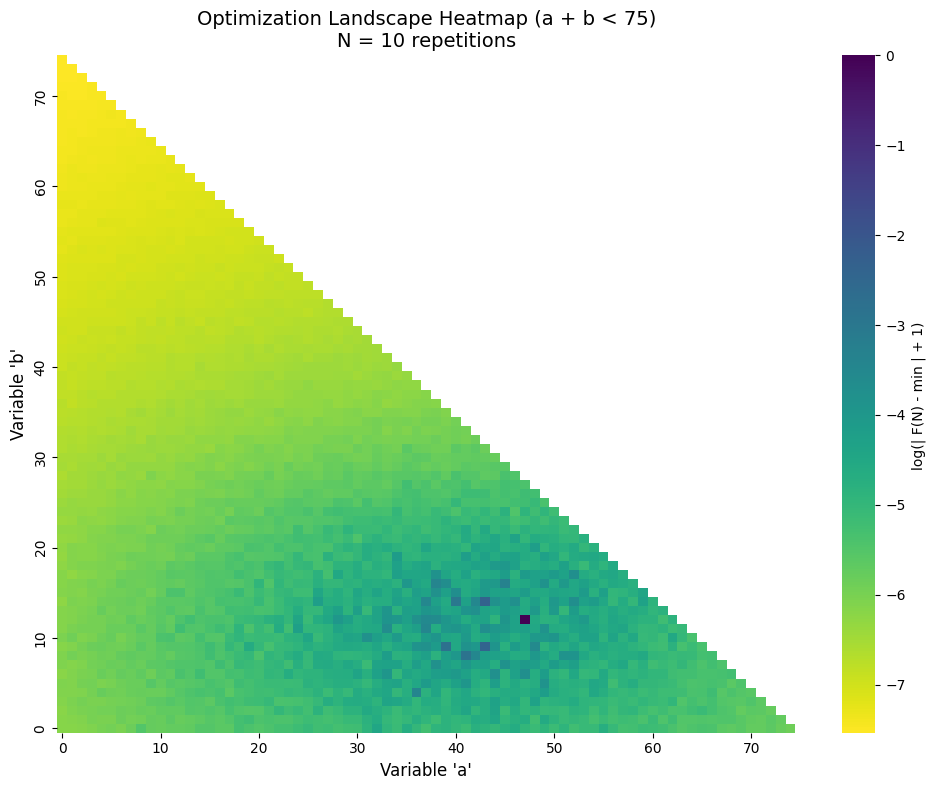

In [546]:
grid_size = 75
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

### Find the best configuration with 80 beds

In [549]:
N = 10 # Number of iteration per point to explore
nb_beds = 80

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean([Relocated(a,b,nb_beds) for _ in range(N)]))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 3240
Computation completed in 74.47 seconds.
The minimum found is at (39, 9) with a value of 2345.5000


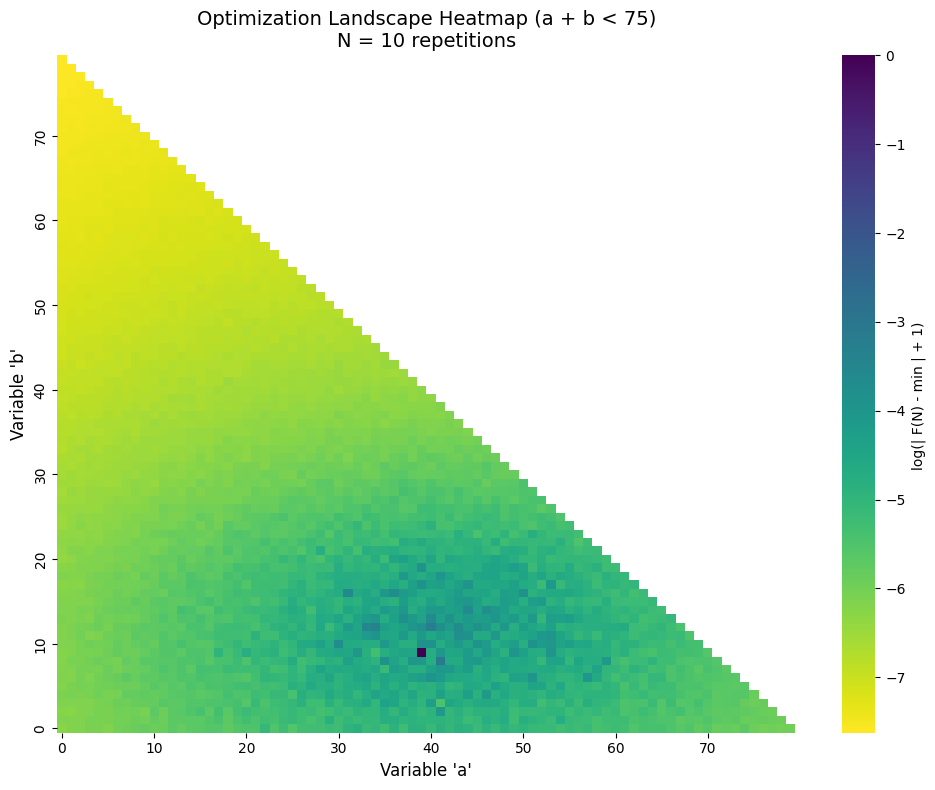

In [550]:
grid_size = 80
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

### Find the best configuration with 100 beds

In [547]:
N = 10 # Number of iteration per point to explore
nb_beds = 100

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean([Relocated(a,b,nb_beds) for _ in range(N)]))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 5050
Computation completed in 130.01 seconds.
The minimum found is at (46, 11) with a value of 1829.1000


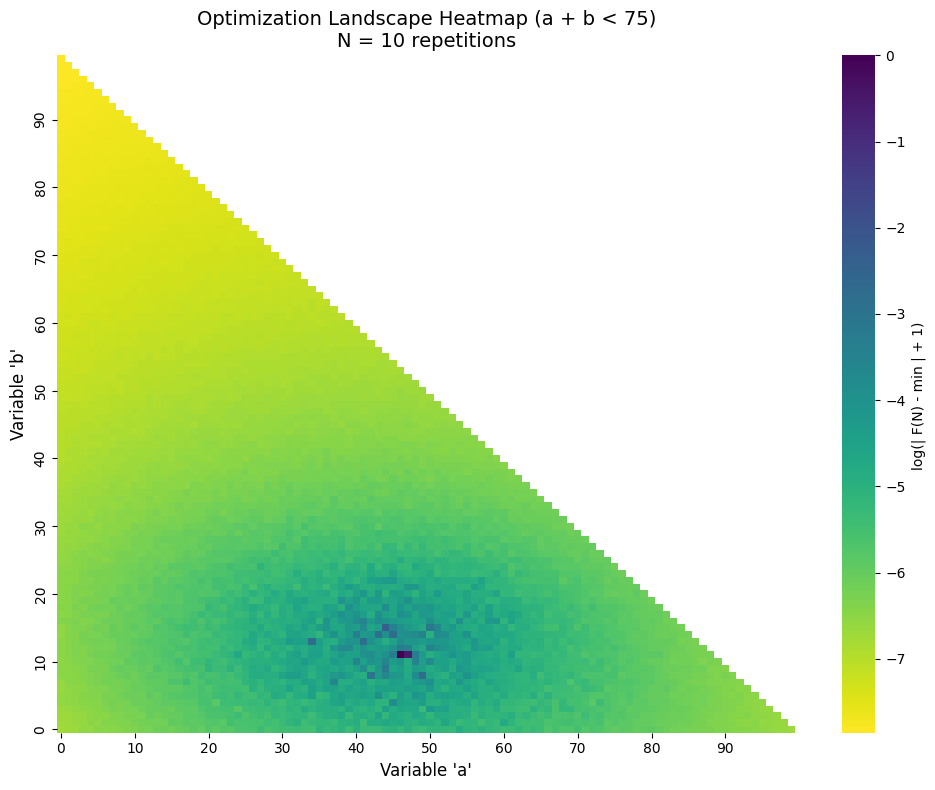

In [548]:
grid_size = 100
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

### Find the best configuration with 50 beds

In [554]:
N = 10 # Number of iteration per point to explore
nb_beds = 50

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean([Relocated(a,b,nb_beds) for _ in range(N)]))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 1275
Computation completed in 23.88 seconds.
The minimum found is at (37, 10) with a value of 3184.6000


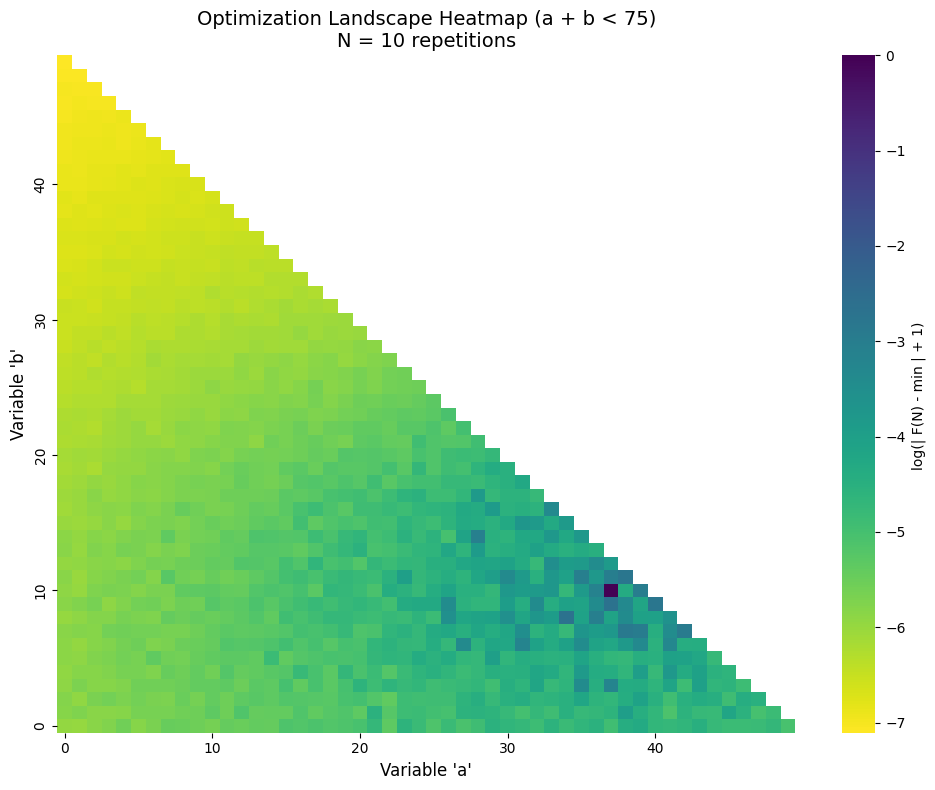

In [555]:
grid_size = 50
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

### Find the best configuration with 30 beds

In [552]:
N = 10 # Number of iteration per point to explore
nb_beds = 30

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean([Relocated(a,b,nb_beds) for _ in range(N)]))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 465
Computation completed in 7.23 seconds.
The minimum found is at (25, 4) with a value of 3802.3000


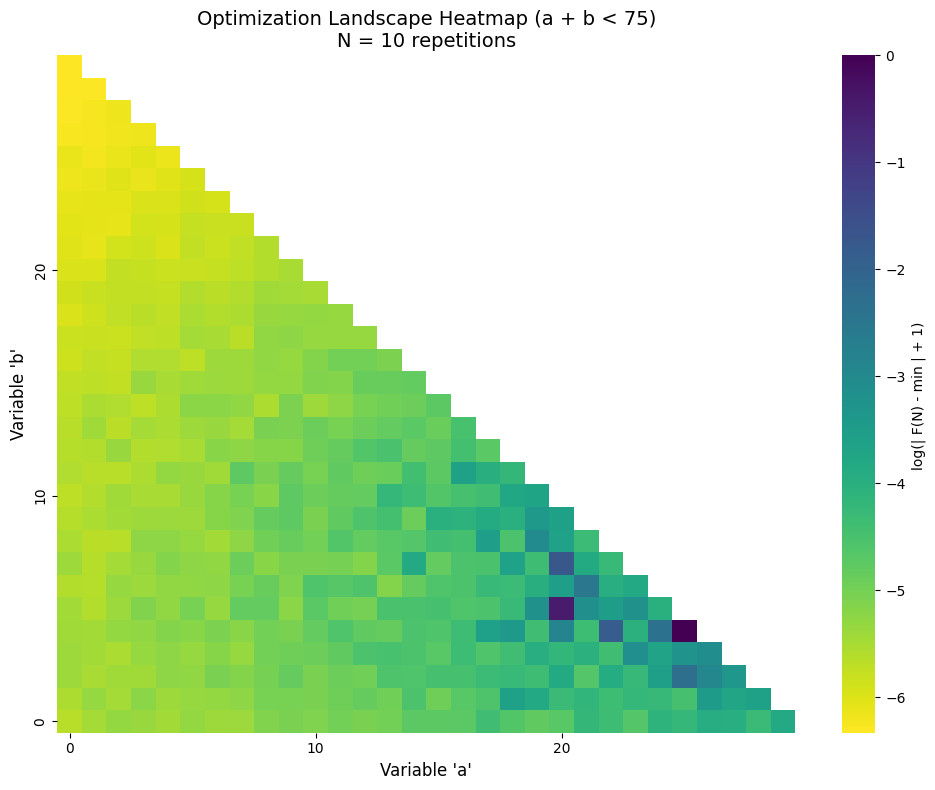

In [553]:
grid_size = 30
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()

### Control variate 

In [628]:
Integral = (H.a*(365**3)/3 + H.b*(365**2)/2) # Integral of lambda(t)dt between 0 and 365
mu_total = (1.2*Integral+6*365) # Average number of people coming every year
var_total = (1.2*Integral+6*365) # Variance of the total number of people coming every year
def Control_variate(nb_A,nb_B,nb_beds,N, original = False):
    R = np.zeros(N)
    Tot = np.zeros(N)
    for i in range(N):
        r,tot = Relocated(nb_A,nb_B,nb_beds,total=True)
        R[i] = r
        Tot[i] = tot
    c = np.cov(R,Tot)[0][1]/var_total
    if original : 
        return R - c*(Tot-mu_total), R
    else :
        return R - c*(Tot-mu_total)

In [665]:
N = 1000
Y,R = Control_variate(nb_A,nb_B,nb_beds=75, N=N, original=True)
R_bar = np.mean(R)
s1 = np.std(R,ddof = 1)

alpha = 0.05
t = stats.t.ppf(1-0.05, df = N-1)
ic_inf1 = R_bar - t*s1/sqrt(N)
ic_sup1 = R_bar + t*s1/sqrt(N)
    

print(f"Estimated number of relocated patients from  {strings[w]} : {R_bar:.2f}, with IC = [{ic_inf1:.2f},{ic_sup1:.2f}]")

R_bar = np.mean(Y)
s2 = np.std(Y,ddof = 1)

alpha = 0.05
t = stats.t.ppf(1-0.05, df = N-1)
ic_inf2 = R_bar - t*s2/sqrt(N)
ic_sup2= R_bar + t*s2/sqrt(N)
    

print(f"Estimated number of relocated patients from  {strings[w]} : {R_bar:.2f}, with IC = [{ic_inf2:.2f},{ic_sup2:.2f}]")
print(f"Variance reduction : {100*(s1**2-s2**2)/(s1**2)} %")
print(f"Variance reduction : {100*(s1-s2)/(s1)} %")

Estimated number of relocated patients from  all wards : 2632.99, with IC = [2628.97,2637.01]
Estimated number of relocated patients from  all wards : 2664.08, with IC = [2661.72,2666.44]
Variance reduction : 65.53148559906904 %
Variance reduction : 41.29010781739507 %


In [647]:
N = 10 # Number of iteration per point to explore
nb_beds = 30

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean(Control_variate(a,b,nb_beds,N)))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 465
Computation completed in 6.68 seconds.
The minimum found is at (26, 3) with a value of 3860.9627


In [ ]:
N = 10 # Number of iteration per point to explore
nb_beds = 75

# Generate the search triangle: a + b < nb_beds
points = [(a, b) for a in range(nb_beds) for b in range(nb_beds) if a + b < nb_beds]

print(f"Number of points to evaluate: {len(points)}")

# Parallelized evaluation across all Apple CPU cores
# n_jobs=-1 utilizes all available cores (both Performance and Efficiency cores)
start_time = time.time()
results = Parallel(n_jobs=-1)(delayed(lambda a,b : np.mean(Control_variate(a,b,nb_beds,N)))(a, b) for a, b in points)
end_time = time.time()

# Find the minimum value
minimum_val = min(results)
best_index = results.index(minimum_val)
best_a, best_b = points[best_index]

print(f"Computation completed in {end_time - start_time:.2f} seconds.")
print(f"The minimum found is at ({best_a}, {best_b}) with a value of {minimum_val:.4f}")

Number of points to evaluate: 2850
Computation completed in 59.90 seconds.
The minimum found is at (48, 12) with a value of 2517.5508


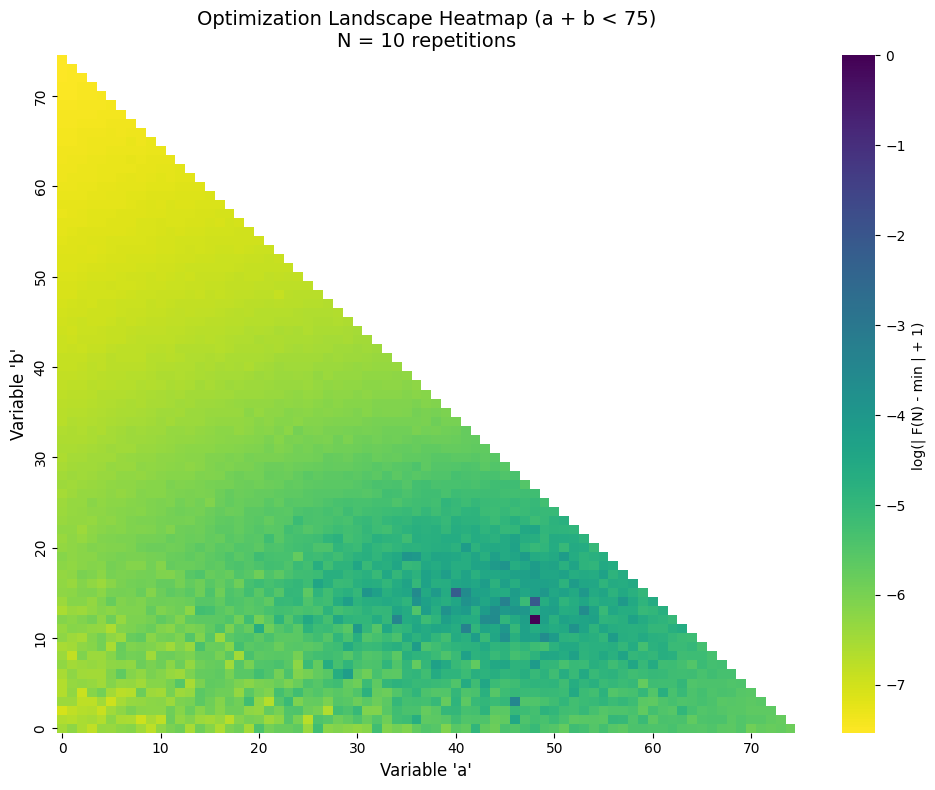

In [649]:
grid_size = 75
eps = 1
heatmap_matrix = np.full((grid_size, grid_size), np.nan)

# Fill the matrix with our results using coordinates (a, b)
for (a, b), value in zip(points, results):
    # We use 'b' as rows (y-axis) and 'a' as columns (x-axis)
    heatmap_matrix[b, a] = -log(abs(value-minimum_val)+eps)

# Setup the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap using Seaborn
# 'viridis_r' is a great colormap (reversed so lower values/minimums are darker/blue)
sns.heatmap(
    heatmap_matrix, 
    cmap="viridis_r", 
    xticklabels=10, 
    yticklabels=10, 
    cbar_kws={'label': 'log(| F(N) - min | + 1) '}
)

# Customizing the chart
plt.title(f"Optimization Landscape Heatmap (a + b < 75)\nN = {N} repetitions", fontsize=14)
plt.xlabel("Variable 'a'", fontsize=12)
plt.ylabel("Variable 'b'", fontsize=12)

# Invert y-axis so (0,0) starts at the bottom-left corner
plt.gca().invert_yaxis()

# Display the plot
plt.tight_layout()
plt.show()